In [4]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [5]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True
)

/home/sharvin/Documents/CV LAB/opencv_tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 100%|██████████| 1/1 [01:22<00:00, 82.96s/ url]
E0000 00:00:1776525779.610353   20829 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776525779.610620   21952 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776525779.631395   20829 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Dataset tf_flowers downloaded and prepared to /home/sharvin/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [6]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [7]:
def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

In [8]:
train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [10]:
def plot_images(original, augmented):
    plt.figure(figsize=(10, 4))
    
    for i in range(len(original)):
        # Original
        plt.subplot(2, len(original), i + 1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")
        
        # Augmented
        plt.subplot(2, len(original), i + 1 + len(original))
        plt.imshow(augmented[i])
        plt.title("Augmented")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [11]:
num_images = 5
sample_images = []

In [12]:

for image, _ in train_ds.take(num_images):
    sample_images.append(image.numpy())

I0000 00:00:1776525890.066820   22396 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1776525890.084827   22401 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [13]:
augmented_images = data_augmentation(
    tf.convert_to_tensor(sample_images),
    training=True
)

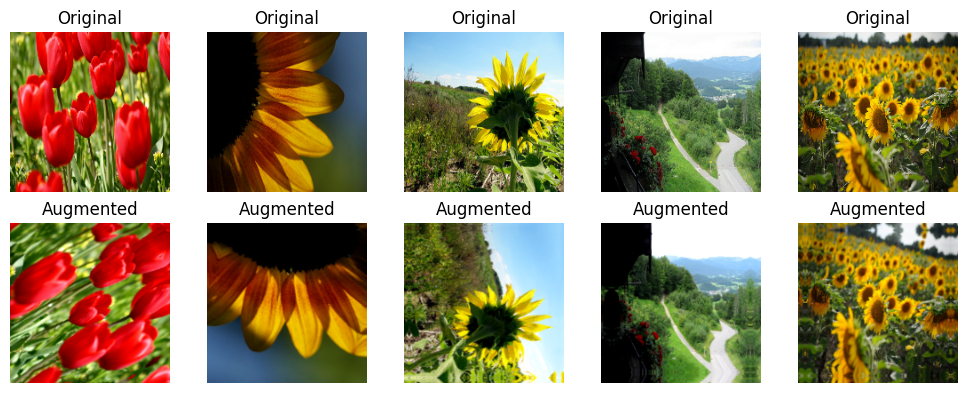

In [14]:
plot_images(sample_images, augmented_images)